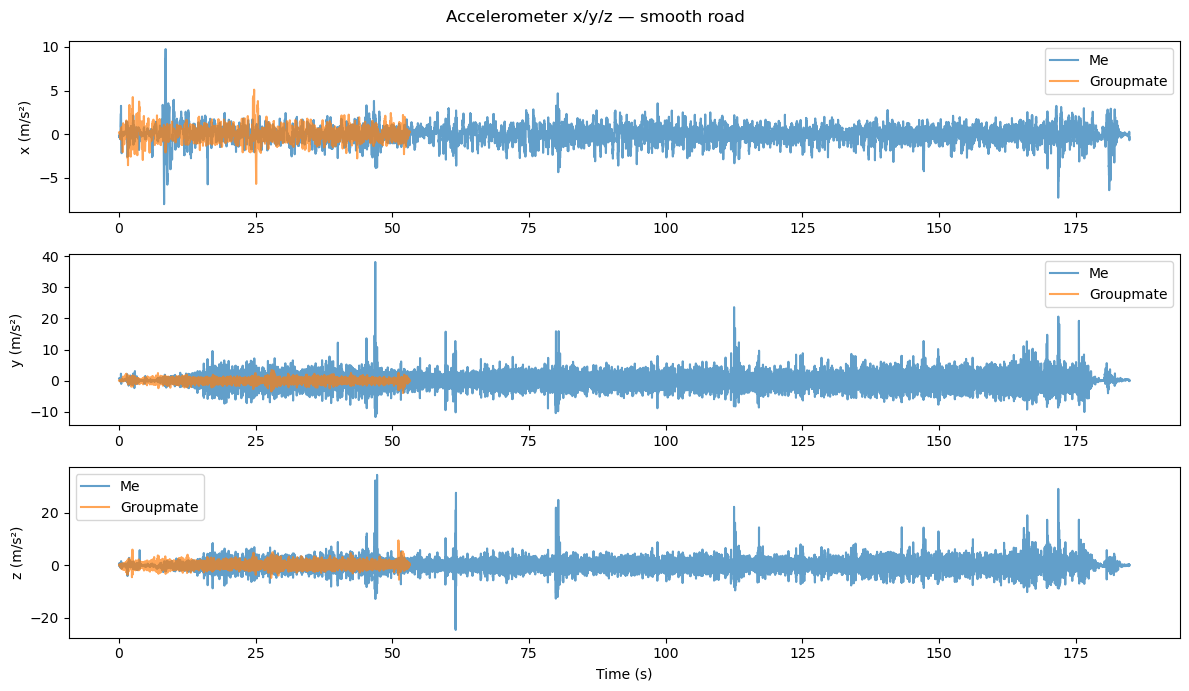

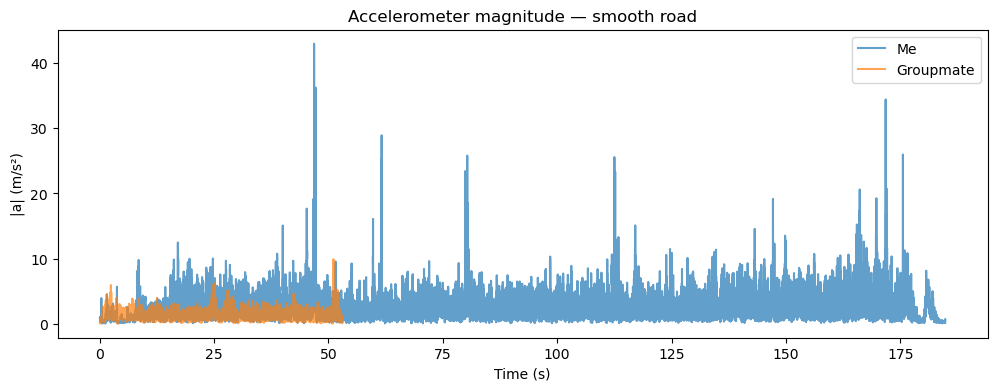

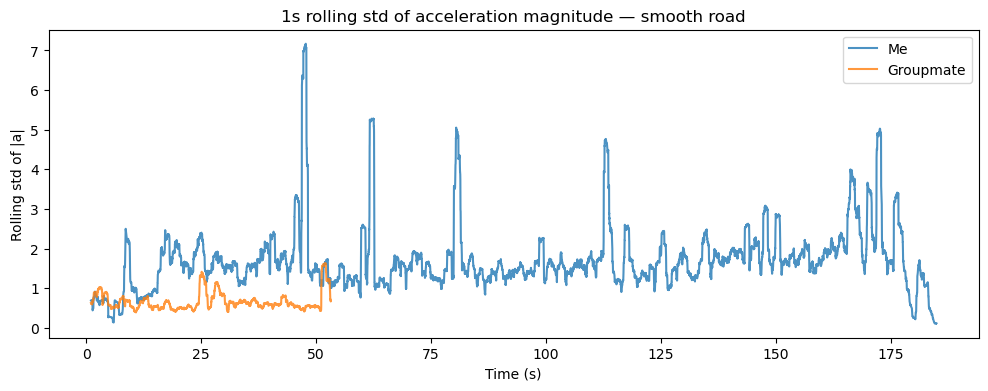

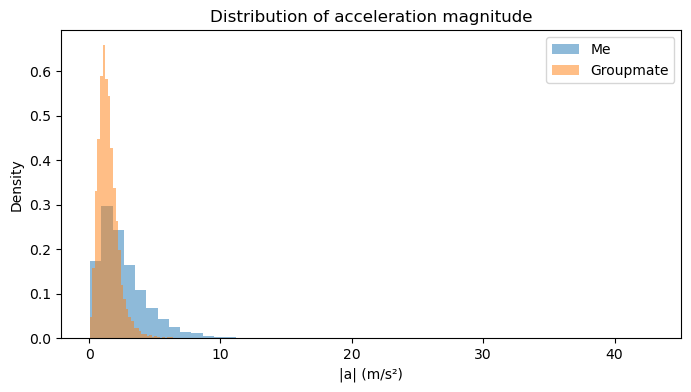

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load both recordings
my_acc   = pd.read_csv('data_raw/smooth/Himanshu/Smooth-2026-09-13_14-36-00/Accelerometer.csv')
mate_acc = pd.read_csv('data_raw/smooth/Yuhan/2026-09-10_18-12-49/Accelerometer.csv')

# 2. Orientation-invariant magnitude (better for cross-person comparison)
for df in (my_acc, mate_acc):
    df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

# 3. Raw x/y/z, side by side (useful to eyeball placement/orientation differences)
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, axis in zip(axes, ['x', 'y', 'z']):
    ax.plot(my_acc['seconds_elapsed'], my_acc[axis], alpha=0.7, label='Me')
    ax.plot(mate_acc['seconds_elapsed'], mate_acc[axis], alpha=0.7, label='Groupmate')
    ax.set_ylabel(f'{axis} (m/s²)')
    ax.legend()
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Accelerometer x/y/z — smooth road')
plt.tight_layout()
plt.show()

# 4. Magnitude overlay (the more honest comparison)
plt.figure(figsize=(12, 4))
plt.plot(my_acc['seconds_elapsed'], my_acc['mag'], alpha=0.7, label='Me')
plt.plot(mate_acc['seconds_elapsed'], mate_acc['mag'], alpha=0.7, label='Groupmate')
plt.xlabel('Time (s)'); plt.ylabel('|a| (m/s²)')
plt.title('Accelerometer magnitude — smooth road')
plt.legend()
plt.show()

# 5. Rolling variance — this is closer to what will actually distinguish smooth vs smooth
window = 100  # ~1 second at 100 Hz
for df in (my_acc, mate_acc):
    df['rolling_std'] = df['mag'].rolling(window).std()

plt.figure(figsize=(12, 4))
plt.plot(my_acc['seconds_elapsed'], my_acc['rolling_std'], alpha=0.8, label='Me')
plt.plot(mate_acc['seconds_elapsed'], mate_acc['rolling_std'], alpha=0.8, label='Groupmate')
plt.xlabel('Time (s)'); plt.ylabel('Rolling std of |a|')
plt.title('1s rolling std of acceleration magnitude — smooth road')
plt.legend()
plt.show()

# 6. Quick distribution comparison — often more informative than the time series itself
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(my_acc['mag'], bins=50, alpha=0.5, label='Me', density=True)
ax.hist(mate_acc['mag'], bins=50, alpha=0.5, label='Groupmate', density=True)
ax.set_xlabel('|a| (m/s²)'); ax.set_ylabel('Density')
ax.set_title('Distribution of acceleration magnitude')
ax.legend()
plt.show()

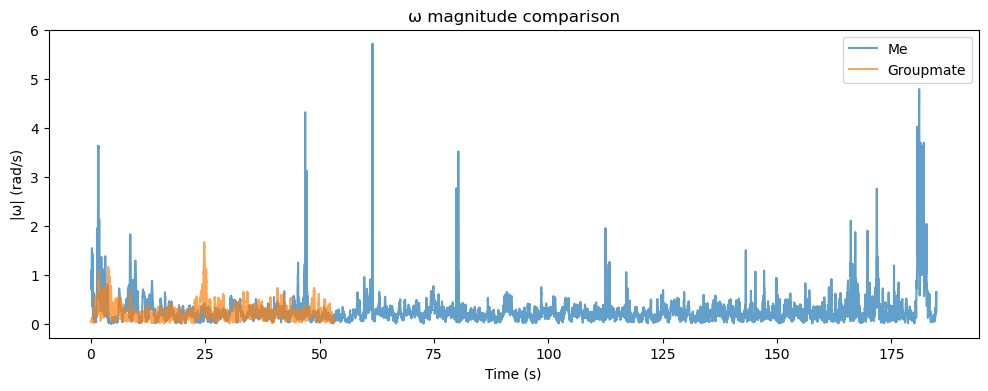

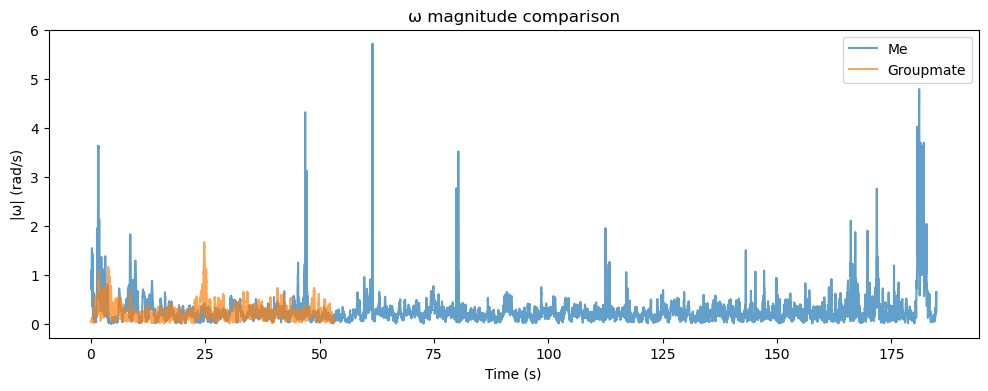

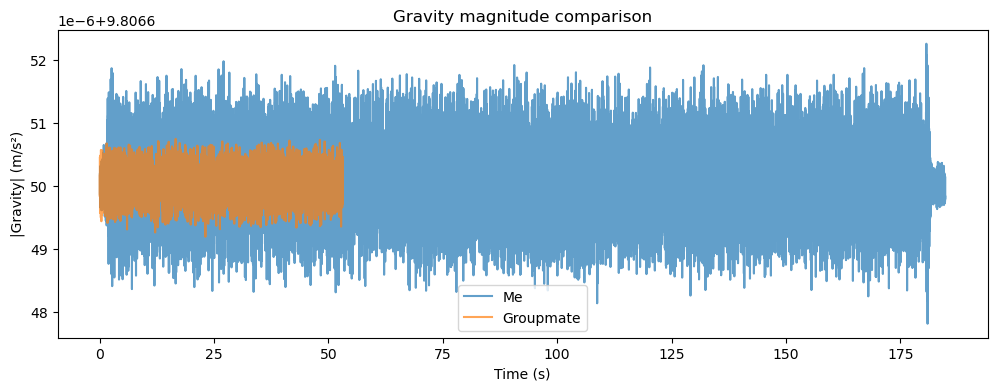

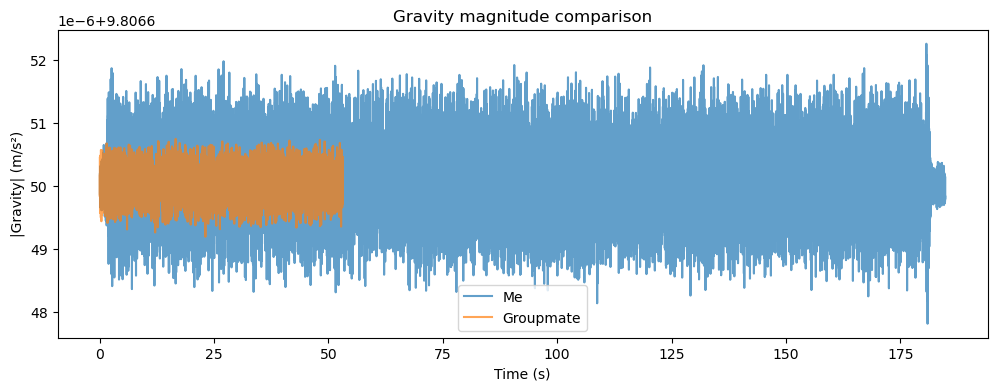

In [6]:
def plot_sensor_comparison(file_name, sensor_label, unit='m/s²'):
    my_df   = pd.read_csv(f'data_raw/smooth/Himanshu/Smooth-2026-09-13_14-36-00/{file_name}')
    mate_df = pd.read_csv(f'data_raw/smooth/Yuhan/2026-09-10_18-12-49/{file_name}')
    for df in (my_df, mate_df):
        df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

    plt.figure(figsize=(12, 4))
    plt.plot(my_df['seconds_elapsed'], my_df['mag'], alpha=0.7, label='Me')
    plt.plot(mate_df['seconds_elapsed'], mate_df['mag'], alpha=0.7, label='Groupmate')
    plt.xlabel('Time (s)'); plt.ylabel(f'|{sensor_label}| ({unit})')
    plt.title(f'{sensor_label} magnitude comparison')
    plt.legend()
    plt.show()

plot_sensor_comparison('Gyroscope.csv', 'ω', unit='rad/s')
plot_sensor_comparison('Gyroscope.csv', 'ω', unit='rad/s')
#plot_sensor_comparison('Gravity.csv', 'g', unit='m/s²')

plot_sensor_comparison('Gravity.csv','Gravity')
plot_sensor_comparison('Gravity.csv','Gravity')


